In [3]:
import os
import sys
from IPython.display import Latex, display

sys.path.append('./')
BASE_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(BASE_DIR, 'data')
PLOT_DIR = os.path.join(BASE_DIR, 'plot')

import numpy as np

def r2_score(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)

def rmse_score(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mae_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def smape_score(y_true, y_pred):
    return 2 * np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)).clip(1e-6))

def mape_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / np.abs(y_true).clip(1e-6))

class Eps(Number):
    def __init__(self, *args):
        super().__init__(1e-7, nettype='scalar', fitable=False)
    def to_str(self, **kwargs):
        return r'\epsilon' if kwargs.get('latex', False) else 'eps'
eps = Eps()

In [22]:
from ND2.env import *

def prepare_data(name, ratio=0.75):
    import json
    import numpy as np
    data = json.load(open(f'{DATA_DIR}/epidemic/COVID19in{name}.json'))
    case = np.array(data['case'], dtype=np.float64)
    flow = np.array(data['flow'], dtype=np.float64)[np.newaxis, :].repeat(case.shape[0]-1, axis=0)
    Y = case[1:].copy()
    X7 = case[:-1].copy()
    X14 = case[:-1].copy(); X14[1:] += case[:-2]
    F = flow.copy()
    X = dict(
        A=np.array(data['A']),
        G=np.array(data['G']),
        x7=X7/X7.max(),
        x14=X14/X14.max(),
        f=F/F.max(),
        y_max=Y.max(),
        x7_max=X7.max(),
        x14_max=X14.max(),
        f_max=F.max(),
    )
    Y=Y/Y.max()

    x7  = v1 = Variable('x7') # 7 days cases
    x14 = v2 = Variable('x14') # 14 days cases
    f   = e1 = Variable('f') # flow
    
    split = int(len(Y) * ratio)
    train_X = X.copy(); train_X['x7'] = X['x7'][:split]; train_X['x14'] = X['x14'][:split]; train_X['f'] = X['f'][:split]; train_Y = Y[:split]
    test_X = X.copy(); test_X['x7'] = X['x7'][split:]; test_X['x14'] = X['x14'][split:]; test_X['f'] = X['f'][split:]; test_Y = Y[split:]
    # train_X, train_Y = test_X, test_Y

    data = []
    def evaluate(eq:Symbol, n_iter=100, compare_baseline=False):
        if n_iter > 0: eq = eq.fit(train_X, train_Y, n_iter)
        
        pred = eq.eval(**train_X) + 0.0 * train_Y
        true = train_Y
        # r2 = np.mean([r2_score(i, j) for i, j in zip(true.T, pred.T)])
        # rmse = np.mean([rmse_score(i, j) for i, j in zip(true.T, pred.T)])
        # mae = np.mean([mae_score(i, j) for i, j in zip(true.T, pred.T)])
        # smape = np.mean([smape_score(i, j) for i, j in zip(true.T, pred.T)])
        # mape = np.mean([mape_score(i, j) for i, j in zip(true.T, pred.T)])
        r2 = r2_score(true, pred)
        rmse = rmse_score(true, pred)
        mae = mae_score(true, pred)
        smape = smape_score(true, pred)
        mape = mape_score(true, pred)
        print(f'[train] [{name}] R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, SMAPE={smape:.2%}, MAPE={mape:.1%} \t {eq.to_str(number_format=".2f")}')
        
        pred = eq.eval(**test_X) + 0.0 * test_Y
        true = test_Y
        # r2 = np.mean([r2_score(i, j) for i, j in zip(true.T, pred.T)])
        # rmse = np.mean([rmse_score(i, j) for i, j in zip(true.T, pred.T)])
        # mae = np.mean([mae_score(i, j) for i, j in zip(true.T, pred.T)])
        # smape = np.mean([smape_score(i, j) for i, j in zip(true.T, pred.T)])
        # mape = np.mean([mape_score(i, j) for i, j in zip(true.T, pred.T)])
        r2 = r2_score(true, pred)
        rmse = rmse_score(true, pred)
        mae = mae_score(true, pred)
        smape = smape_score(true, pred)
        mape = mape_score(true, pred)
        print(f'[test] [{name}] R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, SMAPE={smape:.2%}, MAPE={mape:.1%} \t {eq.to_str(number_format=".2f")}')
        data.append(dict(r2=r2, rmse=rmse, mae=mae, smape=smape, mape=mape, 
                        eq=eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True), 
                        id=eq.to_str(latex=True, skeleton=True)))
        
        if compare_baseline:
            pred0 = x7.eval(**test_X) + 0.0 * test_Y
            true = test_Y
            r20 = r2_score(true, pred0)
            rmse0 = rmse_score(true, pred0)
            mae0 = mae_score(true, pred0)
            smape0 = smape_score(true, pred0)
            mape0 = mape_score(true, pred0)
            print(f'[{name}] R2={r20:.4f}, RMSE={rmse0:.4f}, MAE={mae0:.4f}, SMAPE={smape0:.2%}, MAPE={mape0:.1%} \t {x7.to_str(number_format=".2f")} (baseline)')

            print(f'\033[32m{name} & {r2:.4f} & {r20:.4f} & {r2/r20-1:.2%} & {rmse:.4f} & {rmse0:.4f} & {rmse/rmse0-1:.2%}\033[0m')

            from scipy.stats import ttest_rel
            mse0 = np.mean(np.abs(test_Y - pred0), axis=0)
            mse = np.mean(np.abs(test_Y - pred), axis=0)
            t_stat, p_value = ttest_rel(mse, mse0)
            print(f'T-test: t_stat={t_stat:.4f}, p_value={p_value:.5f}')

    return X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y

In [23]:
name = 'NYC'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)

# 平凡 Baseline
# evaluate(x7)
# evaluate(x14)
# evaluate(Number(0.0), 10000)
# evaluate(1.0 * x7, 10000)
# evaluate(1.0 * x7 + 0.0 * x14, 10000)
# C = Number(np.ones_like(Y[0]), nettype='node')
# evaluate(C)
# C1 = Number(np.ones_like(Y[0]), nettype='node')  
# C2 = Number(np.zeros_like(Y[0]), nettype='node')
# evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

eq = x7 * (_(0.62) + _(1.66) * x7 + _(-2.0) * x14 + _(0.63) * (_(0.013) + Aggr(Sour(x7))) / (_(0.018) + x14 * Aggr(Number(1, fitable=False))))
evaluate(eq, compare_baseline=True)

pred = eq.eval(**test_X)
baseline = x7.eval(**test_X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(test_Y, pred):.4f} ({r2_score(test_Y, pred)/r2_score(test_Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(test_Y, pred):.4f} ({rmse_score(test_Y, pred)/rmse_score(test_Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(test_Y, pred):.4f} ({mae_score(test_Y, pred)/mae_score(test_Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(test_Y, pred):.2%} ({smape_score(test_Y, pred)/smape_score(test_Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(test_Y, pred):.1%} ({mape_score(test_Y, pred)/mape_score(test_Y, baseline)-1:+.1%})')

[train] [NYC] R2=0.8726, RMSE=0.0233, MAE=0.0092, SMAPE=39.95%, MAPE=20712.6% 	 x7 * (0.66 + 1.62 * x7 + -2.05 * x14 + 0.64 * (0.02 + Aggr(Sour(x7))) / (0.03 + x14 * Aggr(Constant(1.00))))
[test] [NYC] R2=0.7940, RMSE=0.0063, MAE=0.0040, SMAPE=34.10%, MAPE=22242.3% 	 x7 * (0.66 + 1.62 * x7 + -2.05 * x14 + 0.64 * (0.02 + Aggr(Sour(x7))) / (0.03 + x14 * Aggr(Constant(1.00))))
[NYC] R2=0.8379, RMSE=0.0056, MAE=0.0035, SMAPE=33.40%, MAPE=19593.6% 	 x7 (baseline)
NYC & 0.7940 & 0.8379 & -5.24% & 0.0063 & 0.0056 & 12.74%
T-test: t_stat=13.1962, p_value=0.00000


<IPython.core.display.Latex object>

Eq: x7 * (0.66 + 1.62 * x7 + -2.05 * x14 + 0.64 * (0.02 + Aggr(Sour(x7))) / (0.03 + x14 * Aggr(Constant(1.00))))
Latex: x_{7}\left(0.7 + 1.6x_{7} + -2.1x_{14} + \frac{0.6\left(0.0 + \rho(\phi_s(x_{7}))\right)}{0.0 + x_{14} \times \rho(Constant(1.0))}\right)
R2: 0.7940 (-5.2%)
RMSE: 0.0063 (+12.7%)
MAE: 0.0040 (+12.6%)
SMAPE: 34.10% (+2.1%)
MAPE: 22242.3% (+13.5%)


In [6]:
name = 'CHI'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)
X, Y = test_X, test_Y

# # 平凡 Baseline
# evaluate(x7)
# evaluate(x14)
# evaluate(Number(0.0), 10000)
# evaluate(1.0 * x7, 10000)
# evaluate(1.0 * x7 + 0.0 * x14, 10000)
# C = Number(np.ones_like(Y[0]), nettype='node')
# evaluate(C)
# C1 = Number(np.ones_like(Y[0]), nettype='node')  
# C2 = Number(np.zeros_like(Y[0]), nettype='node')
# evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

# 测试发现的公式
eq = x7 * (_(-0.69) + _(3.96) * Aggr(Sour(x7))/(eps+Aggr(Sour(x14*(x7 + _(2.17))))))
evaluate(eq, compare_baseline=True)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[train] [CHI] R2=0.8943, RMSE=0.0251, MAE=0.0103, SMAPE=29.15%, MAPE=573.0% 	 x7 * (-0.82 + 4.01 * Aggr(Sour(x7)) / (eps + Aggr(Sour(x14 * (x7 + 1.99)))))
[test] [CHI] R2=0.8943, RMSE=0.0251, MAE=0.0103, SMAPE=29.15%, MAPE=573.0% 	 x7 * (-0.82 + 4.01 * Aggr(Sour(x7)) / (eps + Aggr(Sour(x14 * (x7 + 1.99)))))
[CHI] R2=0.7500, RMSE=0.0385, MAE=0.0141, SMAPE=31.04%, MAPE=571.5% 	 x7 (baseline)
CHI & 0.8943 & 0.7500 & 19.24% & 0.0251 & 0.0385 & -34.97%
T-test: t_stat=-10.4972, p_value=0.00000


<IPython.core.display.Latex object>

Eq: x7 * (-0.82 + 4.01 * Aggr(Sour(x7)) / (eps + Aggr(Sour(x14 * (x7 + 1.99)))))
Latex: x_{7}\left(-0.8 + \frac{4.0 \times \rho(\phi_s(x_{7}))}{\epsilon + \rho(\phi_s(x_{14}\left(x_{7} + 2.0\right)))}\right)
R2: 0.8943 (+19.2%)
RMSE: 0.0251 (-35.0%)
MAE: 0.0103 (-26.8%)
SMAPE: 29.15% (-6.1%)
MAPE: 573.0% (+0.3%)


In [7]:
name = 'ILS'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)
X, Y = test_X, test_Y

# # 平凡 Baseline
# evaluate(x7)
# evaluate(x14)
# evaluate(Number(0.0), 10000)
# evaluate(1.0 * x7, 10000)
# evaluate(1.0 * x7 + 0.0 * x14, 10000)
# C = Number(np.ones_like(Y[0]), nettype='node')
# evaluate(C)
# C1 = Number(np.ones_like(Y[0]), nettype='node')  
# C2 = Number(np.zeros_like(Y[0]), nettype='node')
# evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

eq = _(1.00) * x7 + _(-0.67) * x14 + _(0.84) * x7 * Sigmoid(_(1.00) / Pow2(Aggr(Sour(x14))))
evaluate(eq, n_iter=100, compare_baseline=True)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[train] [ILS] R2=0.9159, RMSE=0.0060, MAE=0.0010, SMAPE=51.76%, MAPE=1339.9% 	 1.01 * x7 + -0.65 * x14 + 0.85 * x7 * sigmoid(1.00 / Aggr(Sour(x14)) ** 2)
[test] [ILS] R2=0.9159, RMSE=0.0060, MAE=0.0010, SMAPE=51.76%, MAPE=1339.9% 	 1.01 * x7 + -0.65 * x14 + 0.85 * x7 * sigmoid(1.00 / Aggr(Sour(x14)) ** 2)
[ILS] R2=0.8515, RMSE=0.0080, MAE=0.0010, SMAPE=45.31%, MAPE=1431.5% 	 x7 (baseline)
ILS & 0.9159 & 0.8515 & 7.56% & 0.0060 & 0.0080 & -24.74%
T-test: t_stat=-1.1611, p_value=0.24832


<IPython.core.display.Latex object>

Eq: 1.01 * x7 + -0.65 * x14 + 0.85 * x7 * sigmoid(1.00 / Aggr(Sour(x14)) ** 2)
Latex: 1.0x_{7} + -0.7x_{14} + 0.9x_{7} \times sigmoid(\frac{1.0}{\rho(\phi_s(x_{14}))^2})
R2: 0.9159 (+7.6%)
RMSE: 0.0060 (-24.7%)
MAE: 0.0010 (-5.8%)
SMAPE: 51.76% (+14.2%)
MAPE: 1339.9% (-6.4%)


In [8]:
name = 'NYS'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)
X, Y = test_X, test_Y

# # 平凡 Baseline
# evaluate(x7)
# evaluate(x14)
# evaluate(Number(0.0), 10000)
# evaluate(1.0 * x7, 10000)
# evaluate(1.0 * x7 + 0.0 * x14, 10000)
# C = Number(np.ones_like(Y[0]), nettype='node')
# evaluate(C)
# C1 = Number(np.ones_like(Y[0]), nettype='node')  
# C2 = Number(np.zeros_like(Y[0]), nettype='node')
# evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

eq = _(0.26) * x7 - _(0.41) * x14 + _(1.3) * x7 * Sigmoid(Aggr(Sour(Aggr(f) - _(0.053) * x14 * Aggr(Number(1, fitable=False)))))
evaluate(eq, compare_baseline=True)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[train] [NYS] R2=0.8553, RMSE=0.0167, MAE=0.0036, SMAPE=32.43%, MAPE=1526.1% 	 1.00 * x7 - 0.46 * x14 + 0.73 * x7 * sigmoid(Aggr(Sour(Aggr(f) - 0.07 * x14 * Aggr(Constant(1.00)))))
[test] [NYS] R2=0.8553, RMSE=0.0167, MAE=0.0036, SMAPE=32.43%, MAPE=1526.1% 	 1.00 * x7 - 0.46 * x14 + 0.73 * x7 * sigmoid(Aggr(Sour(Aggr(f) - 0.07 * x14 * Aggr(Constant(1.00)))))
[NYS] R2=0.7150, RMSE=0.0235, MAE=0.0039, SMAPE=28.61%, MAPE=1168.5% 	 x7 (baseline)
NYS & 0.8553 & 0.7150 & 19.63% & 0.0167 & 0.0235 & -28.75%
T-test: t_stat=-1.8461, p_value=0.06973


<IPython.core.display.Latex object>

Eq: 1.00 * x7 - 0.46 * x14 + 0.73 * x7 * sigmoid(Aggr(Sour(Aggr(f) - 0.07 * x14 * Aggr(Constant(1.00)))))
Latex: 1.0x_{7} - 0.5x_{14} + 0.7x_{7} \times sigmoid(\rho(\phi_s(\rho(f) - 0.1x_{14} \times \rho(Constant(1.0)))))
R2: 0.8553 (+19.6%)
RMSE: 0.0167 (-28.8%)
MAE: 0.0036 (-6.5%)
SMAPE: 32.43% (+13.4%)
MAPE: 1526.1% (+30.6%)


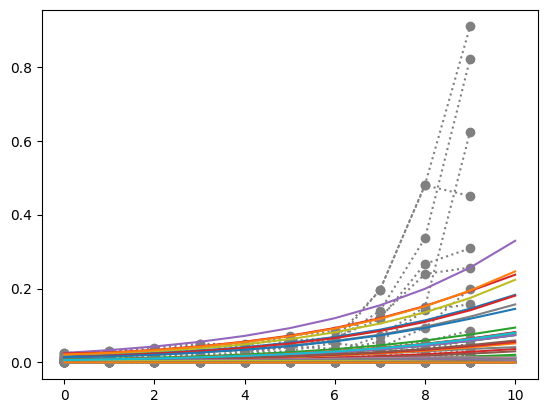

In [9]:
start = 10
T = 10
pred = [{'x7': train_X['x7'][[start]], 'x14': train_X['x14'][[start]], 'f': train_X['f'][[start]], 'A': train_X['A'], 'G': train_X['G']}]
for t in range(T):
    y = eq.eval(**pred[-1])
    # y = y.clip(0, 1) 
    y = y * train_X['y_max']
    x7 = pred[-1]['x7'] * train_X['x7_max']
    pred.append({
        'x7': y / train_X['x7_max'], 
        'x14': (x7 + y) / train_X['x14_max'],
        'f': pred[-1]['f'],
        'A': pred[-1]['A'],
        'G': pred[-1]['G']
    })
pred = np.concatenate([i['x7'] for i in pred], axis=0)

import matplotlib.pyplot as plt
plt.plot(train_X['x7'][start:start+T], 'o:', color='gray')
plt.plot(pred)

In [10]:
name = 'CN'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)
X, Y = test_X, test_Y

# # 平凡 Baseline
# evaluate(x7)
# evaluate(x14)
# evaluate(Number(10.0), 10000)
# evaluate(1.0 * x7, 10000)
# evaluate(1.0 * x7 + 0.0 * x14, 10000)
# C = Number(np.ones_like(Y[0]), nettype='node')
# evaluate(C)
# C1 = Number(np.ones_like(Y[0]), nettype='node')  
# C2 = Number(np.zeros_like(Y[0]), nettype='node')
# evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

eq = _(1.31) * x7 - _(1) * x14 * x7 - _(2.28) * Pow3(x7) + _(3.07) * Aggr(f * Targ(Pow3(x7)))
evaluate(eq, n_iter=1000, compare_baseline=True)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".3g"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[train] [CN] R2=0.9183, RMSE=0.0175, MAE=0.0019, SMAPE=65.93%, MAPE=10216.4% 	 1.31 * x7 - 1.00 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
[test] [CN] R2=0.9183, RMSE=0.0175, MAE=0.0019, SMAPE=65.93%, MAPE=10216.4% 	 1.31 * x7 - 1.00 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
[CN] R2=0.8900, RMSE=0.0203, MAE=0.0021, SMAPE=65.14%, MAPE=8183.7% 	 x7 (baseline)
CN & 0.9183 & 0.8900 & 3.18% & 0.0175 & 0.0203 & -13.81%
T-test: t_stat=-1.2695, p_value=0.21315


<IPython.core.display.Latex object>

Eq: 1.31 * x7 - 1 * x14 * x7 - 2.28 * x7 ** 3 + 3.07 * Aggr(f * Targ(x7 ** 3))
Latex: 1.3x_{7} - 1.0x_{14} \times x_{7} - 2.3 \times x_{7}^3 + 3.1 \times \rho(f \times \phi_t(x_{7}^3))
R2: 0.9183 (+3.2%)
RMSE: 0.0175 (-13.8%)
MAE: 0.0019 (-12.9%)
SMAPE: 65.93% (+1.2%)
MAPE: 10216.4% (+24.8%)


In [11]:
name = 'US'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)
X, Y = test_X, test_Y

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

eq = _(0.62) * x7 * (_(1.9) + x7) / (_(0.81) + _(0.65) * x14) - _(0.49) * x14 + _(0.035) * Aggr(f * Sour(x7))
evaluate(eq, n_iter=1000, compare_baseline=True)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".3g"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[train] [US] R2=0.7870, RMSE=0.0204, MAE=0.0060, SMAPE=29.16%, MAPE=22291.9% 	 x7
[test] [US] R2=0.7870, RMSE=0.0204, MAE=0.0060, SMAPE=29.16%, MAPE=22291.9% 	 x7
[train] [US] R2=0.6484, RMSE=0.0262, MAE=0.0076, SMAPE=33.86%, MAPE=14194.3% 	 x14
[test] [US] R2=0.6484, RMSE=0.0262, MAE=0.0076, SMAPE=33.86%, MAPE=14194.3% 	 x14
[train] [US] R2=-0.0000, RMSE=0.0442, MAE=0.0188, SMAPE=102.64%, MAPE=21301.0% 	 0.02
[test] [US] R2=-0.0000, RMSE=0.0442, MAE=0.0188, SMAPE=102.64%, MAPE=21301.0% 	 0.02
[train] [US] R2=0.7976, RMSE=0.0199, MAE=0.0058, SMAPE=29.83%, MAPE=20180.8% 	 0.91 * x7
[test] [US] R2=0.7976, RMSE=0.0199, MAE=0.0058, SMAPE=29.83%, MAPE=20180.8% 	 0.91 * x7
[train] [US] R2=0.8199, RMSE=0.0188, MAE=0.0056, SMAPE=32.09%, MAPE=25621.9% 	 1.54 * x7 + -0.62 * x14
[test] [US] R2=0.8199, RMSE=0.0188, MAE=0.0056, SMAPE=32.09%, MAPE=25621.9% 	 1.54 * x7 + -0.62 * x14
[train] [US] R2=0.2159, RMSE=0.0392, MAE=0.0140, SMAPE=73.21%, MAPE=34542.7% 	 <0.02 (+0.02)>
[test] [US] R2=0.2159, RM

<IPython.core.display.Latex object>

Eq: 0.616 * x7 * (1.9 + x7) / (0.814 + 0.649 * x14) - 0.491 * x14 + 0.0467 * Aggr(f * Sour(x7))
Latex: \frac{0.6x_{7}\left(1.9 + x_{7}\right)}{0.8 + 0.6x_{14}} - 0.5x_{14} + 0.0 \times \rho(f \times \phi_s(x_{7}))
R2: 0.8370 (+6.4%)
RMSE: 0.0179 (-12.5%)
MAE: 0.0055 (-8.8%)
SMAPE: 30.24% (+3.7%)
MAPE: 27719.6% (+24.3%)


In [12]:
name = 'World'
X, Y, x7, x14, f, data, evaluate, train_X, train_Y, test_X, test_Y = prepare_data(name, 0.5)
X, Y = test_X, test_Y

# 平凡 Baseline
evaluate(x7)
evaluate(x14)
evaluate(Number(0.0), 10000)
evaluate(1.0 * x7, 10000)
evaluate(1.0 * x7 + 0.0 * x14, 10000)
C = Number(np.ones_like(Y[0]), nettype='node')
evaluate(C)
C1 = Number(np.ones_like(Y[0]), nettype='node')  
C2 = Number(np.zeros_like(Y[0]), nettype='node')
evaluate(C1 * x7 + C2 * x14, 10000)

V = len(Y[0])
def _(x): return Number(np.full((V,), x), nettype='node', fitable=True)
def _(x): return Number(x)

eq = _(-0.18) + _(2.1) * x7 + _(-1.0) * x14 + _(0.69) * Sigmoid(_(0.012) * Aggr(f)) / (_(1.9) + _(0.93) * x14)
evaluate(eq, n_iter=1000, compare_baseline=True)

pred = eq.eval(**X)
baseline = x7.eval(**X)
display(Latex("$"+eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True)+"$"))
print('Eq:', eq.to_str(number_format=".2f"))
print('Latex:', eq.to_str(latex=True, number_format='.1f', omit_mul_sign=True))
print(f'R2: {r2_score(Y, pred):.4f} ({r2_score(Y, pred)/r2_score(Y, baseline)-1:+.1%})')
print(f'RMSE: {rmse_score(Y, pred):.4f} ({rmse_score(Y, pred)/rmse_score(Y, baseline)-1:+.1%})')
print(f'MAE: {mae_score(Y, pred):.4f} ({mae_score(Y, pred)/mae_score(Y, baseline)-1:+.1%})')
print(f'SMAPE: {smape_score(Y, pred):.2%} ({smape_score(Y, pred)/smape_score(Y, baseline)-1:+.1%})')
print(f'MAPE: {mape_score(Y, pred):.1%} ({mape_score(Y, pred)/mape_score(Y, baseline)-1:+.1%})')

[train] [World] R2=0.8943, RMSE=0.0086, MAE=0.0015, SMAPE=47.73%, MAPE=2173.8% 	 x7
[test] [World] R2=0.8943, RMSE=0.0086, MAE=0.0015, SMAPE=47.73%, MAPE=2173.8% 	 x7
[train] [World] R2=0.8008, RMSE=0.0118, MAE=0.0020, SMAPE=54.44%, MAPE=2139.6% 	 x14
[test] [World] R2=0.8008, RMSE=0.0118, MAE=0.0020, SMAPE=54.44%, MAPE=2139.6% 	 x14
[train] [World] R2=-0.0000, RMSE=0.0263, MAE=0.0084, SMAPE=162.83%, MAPE=114914.3% 	 0.01
[test] [World] R2=-0.0000, RMSE=0.0263, MAE=0.0084, SMAPE=162.83%, MAPE=114914.3% 	 0.01
[train] [World] R2=0.8972, RMSE=0.0084, MAE=0.0014, SMAPE=47.25%, MAPE=2059.1% 	 0.95 * x7
[test] [World] R2=0.8972, RMSE=0.0084, MAE=0.0014, SMAPE=47.25%, MAPE=2059.1% 	 0.95 * x7
[train] [World] R2=0.9326, RMSE=0.0068, MAE=0.0012, SMAPE=57.28%, MAPE=2816.4% 	 2.11 * x7 + -1.14 * x14
[test] [World] R2=0.9326, RMSE=0.0068, MAE=0.0012, SMAPE=57.28%, MAPE=2816.4% 	 2.11 * x7 + -1.14 * x14
[train] [World] R2=0.3571, RMSE=0.0211, MAE=0.0047, SMAPE=120.67%, MAPE=10568.0% 	 <0.01 (+0.02

<IPython.core.display.Latex object>

Eq: -0.18 + 2.06 * x7 + -1.04 * x14 + 0.69 * sigmoid(0.02 * Aggr(f)) / (1.90 + 0.93 * x14)
Latex: -0.2 + 2.1x_{7} + -1.0x_{14} + \frac{0.7 \times sigmoid(0.0 \times \rho(f))}{1.9 + 0.9x_{14}}
R2: 0.9338 (+4.4%)
RMSE: 0.0068 (-20.9%)
MAE: 0.0014 (-6.5%)
SMAPE: 108.39% (+127.1%)
MAPE: 5221.4% (+140.2%)
